# HW1 房價預測｜P1 Data Preprocessing

**前處理原則**
1. 我們的 testset 有答案、要拿來評分，所以所有「從資料算出來的數字」（眾數、中位數、偏態、縮放參數）**只用 trainset 算**，再套用到 testset。
2. 有好壞順序的類別（例如品質 Ex／Gd／TA／Fa／Po）用**手動指定順序**編成數字。不用 `LabelEncoder`，因為它照字母排序（Ex=0、Fa=1、Gd=2、Po=3、TA=4），會把「普通」排在「極佳」之上。
3. 成交年份、成交月份、交易類型、交易條件是成交後才知道的資訊，依作業「只用預測時拿得到的資訊」的規定，不放進模型。

**流程**
0. 任務定義與資料說明：載入與固定切分、任務定義、資料來源、資料字典、Summary statistics
1. Outliers
2. Target 分布
3. Missing Data
4. Duplicates 與高度相似資料
5. 中文化
6. Encoding（有序類別 → 數字；名目類別 → One-hot）
7. 偏態轉換（Box-Cox）＋ Scaling（RobustScaler）
8. 存檔、理由總表、驗收

**交付（`outputs/p1/`）**
| 檔案 | 內容 | 給誰 |
|---|---|---|
| `train.csv`、`test.csv` | **前處理完成**：全部是數字、沒有缺值，可以直接丟進線性迴歸 | P3 |
| `train_readable.csv`、`test_readable.csv` | 補完缺值的**中文可讀版**（還沒編碼、還沒轉換） | P2 做 EDA、畫圖 |
| `data_split.csv` | 每個 Id 屬於 train 還是 test、在第幾折 | 全組 |

# 0.任務定義與資料說明

## 0.1 載入套件、資料與固定切分

In [1]:
# 問題：載入套件與資料，並依全組固定切分分成 trainset／testset
# 輸入：Kaggle train.csv（1,460 筆，有 SalePrice）、outputs/p1/data_split.csv（固定切分）
# 輸出：train（1,168 筆）、test（292 筆）
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy import stats
from scipy.stats import norm, skew
from scipy.special import boxcox1p
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import RobustScaler

# 中文字型（避免圖上中文變方格）
for font_path in ["C:/Windows/Fonts/msjh.ttc", "/mnt/c/Windows/Fonts/msjh.ttc"]:
    if Path(font_path).exists():
        font_manager.fontManager.addfont(font_path)
available = {f.name for f in font_manager.fontManager.ttflist}
for name in ["Microsoft JhengHei", "Noto Sans CJK TC", "Noto Serif CJK TC", "Noto Sans CJK JP"]:
    if name in available:
        plt.rcParams["font.sans-serif"] = [name] + plt.rcParams["font.sans-serif"]
        break
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = Path("house-prices-advanced-regression-techniques/train.csv")
OUTPUT_DIR = Path("outputs/p1"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

# pd.read_csv 預設讀法（"NA"、"None" 都會變成 NaN，第 3 節再逐欄判斷）
full = pd.read_csv(DATA_PATH)
print("原始資料:", full.shape)

# 全組固定切分：Id 排序 → train_test_split(test_size=292, random_state=42)；trainset 再分 5 折
ids = np.sort(full["Id"].to_numpy())
train_ids, test_ids = train_test_split(ids, test_size=292, shuffle=True, random_state=SEED)
train_ids = np.sort(train_ids)
fold = np.empty(len(train_ids), dtype=int)
for k, (_, va) in enumerate(KFold(5, shuffle=True, random_state=SEED).split(train_ids)):
    fold[va] = k
split_df = pd.DataFrame({"Id": ids, "split": np.where(np.isin(ids, test_ids), "test", "train")})
split_df["cv_fold"] = split_df["Id"].map(dict(zip(train_ids, fold))).astype("Int64")

train = full[full["Id"].isin(train_ids)].sort_values("Id").reset_index(drop=True)
test = full[full["Id"].isin(test_ids)].sort_values("Id").reset_index(drop=True)
train.insert(1, "CV_fold", train["Id"].map(dict(zip(train_ids, fold))))
print(f"trainset: {train.shape}　testset: {test.shape}")
print("testset 只在最後評分用；以下所有「從資料算出來的數字」（眾數、中位數、偏態、縮放參數）都只用 trainset。")

原始資料: (1460, 81)
trainset: (1168, 82)　testset: (292, 81)
testset 只在最後評分用；以下所有「從資料算出來的數字」（眾數、中位數、偏態、縮放參數）都只用 trainset。


## 0.2 任務定義

| 項目 | 定義 |
|---|---|
| 預測目標 | `SalePrice`（總價美元）：美國愛荷華州 Ames 市的住宅**成交價**，單位為**美元（當時的名目價格）** |
| 合理範圍 | 正數；trainset 介於 0.5 節印出的最小值與最大值之間（約 3.5 萬～75 萬美元）。沒有缺值、沒有 ≤ 0 的價格（下方程式檢查） |
| 一筆資料 | **一筆住宅成交紀錄**（一間房子賣出一次）。`Id` 只是 Kaggle 的列編號，不是房產編號 |
| 預測時間點 | 房屋條件都已知、**還沒成交**時估價 |
| 可用的輸入 | 房屋本身的條件（面積、品質、年份、設施、地段等） |
| 不可用的輸入 | `YrSold` 成交年、`MoSold` 成交月、`SaleType` 交易類型、`SaleCondition` 交易條件：成交時才確定，預測時拿不到，不放進模型 |
| 研究範圍 | 同一城市、同一時期（2006–2010）的新物件估價；隨機切分不代表能預測未來年份 |

In [2]:
# 問題：確認目標的單位與合理範圍
# 輸入：full（1,460 筆原始資料）
# 輸出：SalePrice 是否有缺值、是否都 > 0；成交年份範圍
assert full["SalePrice"].notna().all() and (full["SalePrice"] > 0).all()
print("SalePrice：沒有缺值、全部 > 0 ✅")
print("成交年份範圍:", full["YrSold"].min(), "～", full["YrSold"].max(),
      "｜ 各年筆數:", full["YrSold"].value_counts().sort_index().to_dict())

SalePrice：沒有缺值、全部 > 0 ✅
成交年份範圍: 2006 ～ 2010 ｜ 各年筆數: {2006: 314, 2007: 329, 2008: 304, 2009: 338, 2010: 175}


## 0.3 資料來源

| 項目 | 內容 |
|---|---|
| 資料集 | Kaggle 競賽〈House Prices – Advanced Regression Techniques〉 https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques |
| 原始出處 | De Cock, D. (2011). *Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project.* Journal of Statistics Education, 19(3). |
| 收集方式 | Ames 市估價辦公室（Assessor's Office）的住宅成交紀錄，由 De Cock 整理成教學用資料集 |
| 時間範圍 | 2006–2010 年成交（0.2 節程式確認） |
| 規模 | ZIP 內 `train.csv` 1,460 筆 × 81 欄（有成交價，本作業唯一使用的資料）；`test.csv` 1,459 筆（沒有成交價，本作業不用） |
| 下載日期 | 2026/10/9 |
| 授權 | MIT License（Kaggle 資料頁標示）：可使用、修改、再散布，須保留授權聲明並註明出處 |
| 版本 | ZIP 檔 SHA-256：`65f769a9157a2581671957ed08da8a8162d53e67b4e9970ee856b634deb11d9f` |

## 0.4 資料字典（Data Dictionary）
81 個原始欄位逐一列出：中文名稱、意義、單位、型態、角色，以及本 notebook 對它做的處理。
型態說明：**連續**（面積、長度、金額）、**計數**（房間數等）、**年份／月份**、**名目**（沒有大小順序的類別）、**有序**（有好壞順序的類別或 1–10 分）。

In [3]:
# 問題：建立 81 欄資料字典（英文 → 中文、意義、單位、型態、處理方式）
# 輸入：欄位定義（依 data_description.txt 整理）
# 輸出：DATA_DICT 表；rename_dict、value_map（第 5 節中文化會用到）
_DICT = [
    ("Id", "列識別碼（Kaggle 編號，不是房產 ID）", "—", "id"),
    ("MSSubClass", "住宅類型代碼（層數／年代／PUD）", "代碼", "nominal"),
    ("MSZoning", "土地使用分區", "—", "nominal"),
    ("LotFrontage", "臨街長度", "ft", "continuous"),
    ("LotArea", "地塊面積", "ft²", "continuous"),
    ("Street", "連外道路鋪面", "—", "nominal"),
    ("Alley", "巷道通行類型（NA＝無巷道）", "—", "nominal"),
    ("LotShape", "地塊形狀規則度", "—", "ordinal_text"),
    ("LandContour", "地形平坦度", "—", "nominal"),
    ("Utilities", "可用公用設施", "—", "nominal"),
    ("LotConfig", "地塊配置（角地、內側等）", "—", "nominal"),
    ("LandSlope", "地塊坡度", "—", "ordinal_text"),
    ("Neighborhood", "Ames 市內社區", "—", "nominal"),
    ("Condition1", "鄰近條件 1（幹道、鐵路、公園等）", "—", "nominal"),
    ("Condition2", "鄰近條件 2（若有第二項）", "—", "nominal"),
    ("BldgType", "建物型態（獨棟、雙拼、連棟等）", "—", "nominal"),
    ("HouseStyle", "樓層樣式", "—", "nominal"),
    ("OverallQual", "整體材料與施工品質", "評級 1–10", "ordinal_numeric"),
    ("OverallCond", "整體狀況", "評級 1–10", "ordinal_numeric"),
    ("YearBuilt", "原始建造年份", "西元年", "year"),
    ("YearRemodAdd", "改建年份（無改建＝建造年）", "西元年", "year"),
    ("RoofStyle", "屋頂樣式", "—", "nominal"),
    ("RoofMatl", "屋頂材料", "—", "nominal"),
    ("Exterior1st", "外牆材料 1", "—", "nominal"),
    ("Exterior2nd", "外牆材料 2（若多於一種）", "—", "nominal"),
    ("MasVnrType", "砌面類型（None＝無砌面，NA＝未知）", "—", "nominal"),
    ("MasVnrArea", "砌面面積", "ft²", "continuous"),
    ("ExterQual", "外部材料品質", "—", "ordinal_text"),
    ("ExterCond", "外部材料現況", "—", "ordinal_text"),
    ("Foundation", "地基類型", "—", "nominal"),
    ("BsmtQual", "地下室高度等級（NA＝無地下室）", "—", "ordinal_text"),
    ("BsmtCond", "地下室整體狀況", "—", "ordinal_text"),
    ("BsmtExposure", "地下室採光／出入（No＝無外露，為有效類別）", "—", "ordinal_text"),
    ("BsmtFinType1", "地下室完工區 1 品質", "—", "ordinal_text"),
    ("BsmtFinSF1", "地下室完工區 1 面積", "ft²", "continuous"),
    ("BsmtFinType2", "地下室完工區 2 品質（若有）", "—", "ordinal_text"),
    ("BsmtFinSF2", "地下室完工區 2 面積", "ft²", "continuous"),
    ("BsmtUnfSF", "地下室未完工面積", "ft²", "continuous"),
    ("TotalBsmtSF", "地下室總面積", "ft²", "continuous"),
    ("Heating", "暖氣類型", "—", "nominal"),
    ("HeatingQC", "暖氣品質", "—", "ordinal_text"),
    ("CentralAir", "是否有中央空調", "Y/N", "nominal"),
    ("Electrical", "電力系統", "—", "nominal"),
    ("1stFlrSF", "一樓面積", "ft²", "continuous"),
    ("2ndFlrSF", "二樓面積", "ft²", "continuous"),
    ("LowQualFinSF", "低品質完工面積（各樓層）", "ft²", "continuous"),
    ("GrLivArea", "地上居住面積", "ft²", "continuous"),
    ("BsmtFullBath", "地下室全套衛浴數", "間", "count"),
    ("BsmtHalfBath", "地下室半套衛浴數", "間", "count"),
    ("FullBath", "地上全套衛浴數", "間", "count"),
    ("HalfBath", "地上半套衛浴數", "間", "count"),
    ("BedroomAbvGr", "地上臥室數（不含地下室）", "間", "count"),
    ("KitchenAbvGr", "地上廚房數", "間", "count"),
    ("KitchenQual", "廚房品質", "—", "ordinal_text"),
    ("TotRmsAbvGrd", "地上房間總數（不含衛浴）", "間", "count"),
    ("Functional", "居家功能性（扣分程度）", "—", "ordinal_text"),
    ("Fireplaces", "壁爐數", "座", "count"),
    ("FireplaceQu", "壁爐品質（NA＝無壁爐）", "—", "ordinal_text"),
    ("GarageType", "車庫位置／類型（NA＝無車庫）", "—", "nominal"),
    ("GarageYrBlt", "車庫建造年份", "西元年", "year"),
    ("GarageFinish", "車庫內裝完工程度", "—", "ordinal_text"),
    ("GarageCars", "車庫容量", "車位", "count"),
    ("GarageArea", "車庫面積", "ft²", "continuous"),
    ("GarageQual", "車庫品質", "—", "ordinal_text"),
    ("GarageCond", "車庫狀況", "—", "ordinal_text"),
    ("PavedDrive", "車道鋪面", "—", "nominal"),
    ("WoodDeckSF", "木平台面積", "ft²", "continuous"),
    ("OpenPorchSF", "開放式門廊面積", "ft²", "continuous"),
    ("EnclosedPorch", "封閉式門廊面積", "ft²", "continuous"),
    ("3SsnPorch", "三季門廊面積", "ft²", "continuous"),
    ("ScreenPorch", "紗窗門廊面積", "ft²", "continuous"),
    ("PoolArea", "泳池面積", "ft²", "continuous"),
    ("PoolQC", "泳池品質（NA＝無泳池）", "—", "ordinal_text"),
    ("Fence", "圍籬品質（NA＝無圍籬）", "—", "ordinal_text"),
    ("MiscFeature", "其他設施（棚屋、電梯、網球場等；NA＝無）", "—", "nominal"),
    ("MiscVal", "其他設施價值", "USD", "continuous"),
    ("MoSold", "成交月份", "月 1–12", "month"),
    ("YrSold", "成交年份", "西元年", "year"),
    ("SaleType", "交易類型", "—", "nominal"),
    ("SaleCondition", "交易條件", "—", "nominal"),
    ("SalePrice", "成交價（預測目標）", "USD（名目）", "target"),
]
rename_dict = {
    "Id": "編號", "MSSubClass": "住宅類型", "MSZoning": "土地分區",
    "LotFrontage": "臨街長度英尺", "LotArea": "地塊面積平方英尺",
    "Street": "道路鋪面", "Alley": "巷道", "LotShape": "地塊形狀", "LandContour": "地形",
    "Utilities": "公用設施", "LotConfig": "地塊位置", "LandSlope": "坡度", "Neighborhood": "社區",
    "Condition1": "鄰近條件1", "Condition2": "鄰近條件2", "BldgType": "建物型態", "HouseStyle": "樓層樣式",
    "OverallQual": "整體品質1到10分", "OverallCond": "整體狀況1到10分",
    "YearBuilt": "建造年份", "YearRemodAdd": "改建年份",
    "RoofStyle": "屋頂樣式", "RoofMatl": "屋頂材料", "Exterior1st": "外牆材料1", "Exterior2nd": "外牆材料2",
    "MasVnrType": "砌面類型", "MasVnrArea": "砌面面積平方英尺",
    "ExterQual": "外牆品質", "ExterCond": "外牆狀況", "Foundation": "地基類型",
    "BsmtQual": "地下室高度品質", "BsmtCond": "地下室狀況", "BsmtExposure": "地下室採光",
    "BsmtFinType1": "地下室完工區1品質", "BsmtFinSF1": "地下室完工區1面積平方英尺",
    "BsmtFinType2": "地下室完工區2品質", "BsmtFinSF2": "地下室完工區2面積平方英尺",
    "BsmtUnfSF": "地下室未完工面積平方英尺", "TotalBsmtSF": "地下室總面積平方英尺",
    "Heating": "暖氣類型", "HeatingQC": "暖氣品質", "CentralAir": "中央空調", "Electrical": "電力系統",
    "1stFlrSF": "一樓面積平方英尺", "2ndFlrSF": "二樓面積平方英尺",
    "LowQualFinSF": "低品質完工面積平方英尺", "GrLivArea": "地上居住面積平方英尺",
    "BsmtFullBath": "地下室全套衛浴數", "BsmtHalfBath": "地下室半套衛浴數",
    "FullBath": "地上全套衛浴數", "HalfBath": "地上半套衛浴數",
    "BedroomAbvGr": "地上臥室數", "KitchenAbvGr": "地上廚房數", "KitchenQual": "廚房品質",
    "TotRmsAbvGrd": "地上房間總數", "Functional": "居家功能性",
    "Fireplaces": "壁爐數", "FireplaceQu": "壁爐品質",
    "GarageType": "車庫類型", "GarageYrBlt": "車庫建造年份", "GarageFinish": "車庫內裝",
    "GarageCars": "車庫車位數", "GarageArea": "車庫面積平方英尺",
    "GarageQual": "車庫品質", "GarageCond": "車庫狀況", "PavedDrive": "車道鋪面",
    "WoodDeckSF": "木平台面積平方英尺", "OpenPorchSF": "開放門廊面積平方英尺",
    "EnclosedPorch": "封閉門廊面積平方英尺", "3SsnPorch": "三季門廊面積平方英尺",
    "ScreenPorch": "紗窗門廊面積平方英尺", "PoolArea": "泳池面積平方英尺", "PoolQC": "泳池品質",
    "Fence": "圍籬", "MiscFeature": "其他設施", "MiscVal": "其他設施價值美元",
    "MoSold": "成交月份", "YrSold": "成交年份", "SaleType": "交易類型", "SaleCondition": "交易條件",
    "SalePrice": "總價美元",
}
Q = {"Ex": "極佳", "Gd": "良好", "TA": "普通", "Fa": "尚可", "Po": "差"}
EXTERIOR = {"AsbShng": "石棉瓦", "AsphShn": "瀝青瓦", "BrkComm": "一般磚", "Brk Cmn": "一般磚",
            "BrkFace": "面磚", "CBlock": "煤渣磚", "CemntBd": "水泥板", "CmentBd": "水泥板",
            "HdBoard": "硬質纖維板", "ImStucc": "仿灰泥", "MetalSd": "金屬壁板", "Other": "其他",
            "Plywood": "夾板", "PreCast": "預鑄板", "Stone": "石材", "Stucco": "灰泥",
            "VinylSd": "乙烯基壁板", "Wd Sdng": "木壁板", "WdShing": "木瓦", "Wd Shng": "木瓦"}
CONDITION = {"Artery": "鄰近主幹道", "Feedr": "鄰近支線道路", "Norm": "正常",
             "RRNn": "南北向鐵路200英尺內", "RRAn": "緊鄰南北向鐵路",
             "PosN": "鄰近公園綠地等正面設施", "PosA": "緊鄰公園綠地等正面設施",
             "RRNe": "東西向鐵路200英尺內", "RRAe": "緊鄰東西向鐵路"}
BSMT_FIN = {"GLQ": "優良居住空間", "ALQ": "普通居住空間", "BLQ": "低於平均居住空間",
            "Rec": "一般娛樂空間", "LwQ": "低品質空間", "Unf": "未完工"}

value_map = {
    "MSSubClass": {"20": "1層樓(1946年後)", "30": "1層樓(1945年前)", "40": "1層樓含完工閣樓",
                   "45": "1.5層樓(未完工)", "50": "1.5層樓(已完工)", "60": "2層樓(1946年後)",
                   "70": "2層樓(1945年前)", "75": "2.5層樓", "80": "錯層式", "85": "錯層玄關式",
                   "90": "雙拼住宅", "120": "1層樓社區住宅(1946年後)", "150": "1.5層樓社區住宅",
                   "160": "2層樓社區住宅(1946年後)", "180": "社區錯層住宅", "190": "兩戶改建住宅"},
    "MSZoning": {"A": "農業區", "C": "商業區", "C (all)": "商業區", "FV": "浮動村住宅區", "I": "工業區",
                 "RH": "高密度住宅區", "RL": "低密度住宅區", "RP": "低密度公園住宅區", "RM": "中密度住宅區"},
    "Street": {"Grvl": "碎石路", "Pave": "柏油路"},
    "Alley": {"Grvl": "碎石巷", "Pave": "柏油巷"},
    "LotShape": {"Reg": "規則", "IR1": "略不規則", "IR2": "中度不規則", "IR3": "不規則"},
    "LandContour": {"Lvl": "平坦", "Bnk": "坡堤", "HLS": "山坡", "Low": "低窪"},
    "Utilities": {"AllPub": "水電瓦斯污水齊全", "NoSewr": "無污水", "NoSeWa": "僅水電瓦斯", "ELO": "僅電"},
    "LotConfig": {"Inside": "內側地", "Corner": "角地", "CulDSac": "死巷底", "FR2": "兩面臨路", "FR3": "三面臨路"},
    "LandSlope": {"Gtl": "緩坡", "Mod": "中坡", "Sev": "陡坡"},
    "Neighborhood": {
        "Blmngtn": "布魯明頓高地(Blmngtn)", "Blueste": "藍莖(Blueste)", "BrDale": "布萊爾戴爾(BrDale)",
        "BrkSide": "布魯克賽德(BrkSide)", "ClearCr": "清溪(ClearCr)", "CollgCr": "學院溪(CollgCr)",
        "Crawfor": "克勞福德(Crawfor)", "Edwards": "愛德華茲(Edwards)", "Gilbert": "吉爾伯特(Gilbert)",
        "IDOTRR": "交通部與鐵路區(IDOTRR)", "MeadowV": "草地村(MeadowV)", "Mitchel": "米切爾(Mitchel)",
        "NAmes": "北艾姆斯(NAmes)", "NoRidge": "北嶺(NoRidge)", "NPkVill": "北公園村(NPkVill)",
        "NridgHt": "北嶺高地(NridgHt)", "NWAmes": "西北艾姆斯(NWAmes)", "OldTown": "舊城區(OldTown)",
        "SWISU": "州立大學西南(SWISU)", "Sawyer": "索耶(Sawyer)", "SawyerW": "西索耶(SawyerW)",
        "Somerst": "薩默塞特(Somerst)", "StoneBr": "石橋(StoneBr)", "Timber": "林地(Timber)",
        "Veenker": "文克(Veenker)"},
    "Condition1": CONDITION, "Condition2": CONDITION,
    "BldgType": {"1Fam": "獨棟", "2fmCon": "兩戶改建", "2FmCon": "兩戶改建", "Duplex": "雙拼", "Duplx": "雙拼",
                 "TwnhsE": "連棟邊間", "Twnhs": "連棟中間", "TwnhsI": "連棟中間"},
    "HouseStyle": {"1Story": "1層樓", "1.5Fin": "1.5層(二樓完工)", "1.5Unf": "1.5層(二樓未完工)",
                   "2Story": "2層樓", "2.5Fin": "2.5層(三樓完工)", "2.5Unf": "2.5層(三樓未完工)",
                   "SFoyer": "錯層玄關", "SLvl": "錯層"},
    "RoofStyle": {"Flat": "平頂", "Gable": "山形頂", "Gambrel": "穀倉頂", "Hip": "四坡頂",
                  "Mansard": "孟莎式", "Shed": "單坡頂"},
    "RoofMatl": {"ClyTile": "黏土瓦", "CompShg": "標準瀝青瓦", "Membran": "防水膜", "Metal": "金屬",
                 "Roll": "捲材", "Tar&Grv": "焦油碎石", "WdShake": "劈製木瓦", "WdShngl": "鋸製木瓦"},
    "Exterior1st": EXTERIOR, "Exterior2nd": EXTERIOR,
    "MasVnrType": {"BrkCmn": "一般磚", "BrkFace": "面磚", "CBlock": "煤渣磚", "None": "無砌面", "Stone": "石材"},
    "ExterQual": Q, "ExterCond": Q,
    "Foundation": {"BrkTil": "磚與瓦", "CBlock": "煤渣磚", "PConc": "澆置混凝土", "Slab": "板式",
                   "Stone": "石材", "Wood": "木材"},
    "BsmtQual": Q, "BsmtCond": Q,
    "BsmtExposure": {"Gd": "採光良好", "Av": "採光普通", "Mn": "採光少", "No": "無採光"},
    "BsmtFinType1": BSMT_FIN, "BsmtFinType2": BSMT_FIN,
    "Heating": {"Floor": "地板暖爐", "GasA": "瓦斯熱風", "GasW": "瓦斯熱水", "Grav": "重力式暖爐",
                "OthW": "非瓦斯熱水", "Wall": "壁掛暖爐"},
    "HeatingQC": Q, "CentralAir": {"Y": "有", "N": "無"},
    "Electrical": {"SBrkr": "標準斷路器", "FuseA": "保險絲(良)", "FuseF": "保險絲(普通)",
                   "FuseP": "保險絲(差)", "Mix": "混合"},
    "KitchenQual": Q,
    "Functional": {"Typ": "正常", "Min1": "輕微扣分1", "Min2": "輕微扣分2", "Mod": "中度扣分",
                   "Maj1": "重大扣分1", "Maj2": "重大扣分2", "Sev": "嚴重受損", "Sal": "僅剩殘值"},
    "FireplaceQu": Q,
    "GarageType": {"2Types": "多種車庫", "Attchd": "連接主屋", "Basment": "地下室車庫",
                   "BuiltIn": "內建車庫", "CarPort": "車棚", "Detchd": "獨立車庫"},
    "GarageFinish": {"Fin": "已完工", "RFn": "粗略完工", "Unf": "未完工"},
    "GarageQual": Q, "GarageCond": Q,
    "PavedDrive": {"Y": "鋪面", "P": "部分鋪面", "N": "泥土或碎石"},
    "PoolQC": Q,
    "Fence": {"GdPrv": "隱私性佳", "MnPrv": "隱私性低", "GdWo": "木圍籬佳", "MnWw": "簡易鐵絲網"},
    "MiscFeature": {"Elev": "電梯", "Gar2": "第二車庫", "Othr": "其他", "Shed": "儲藏棚", "TenC": "網球場"},
    "SaleType": {"WD": "一般保證契約", "CWD": "現金保證契約", "VWD": "退伍軍人貸款", "New": "新屋",
                 "COD": "法院或遺產拍賣", "Con": "一般分期合約", "ConLw": "低頭期低利合約",
                 "ConLI": "低利合約", "ConLD": "低頭期合約", "Oth": "其他"},
    "SaleCondition": {"Normal": "一般交易", "Abnorml": "異常交易(如法拍)", "AdjLand": "購買相鄰土地",
                      "Alloca": "兩筆相連物件分配", "Family": "親友交易", "Partial": "預售屋(估價時未完工)"},
}

TYPE_ZH = {"id": "編號", "target": "目標", "continuous": "連續", "count": "計數", "year": "年份", "month": "月份",
           "nominal": "名目", "ordinal_text": "有序", "ordinal_numeric": "有序(1–10分)"}
ORDINAL_EN = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual",
              "GarageCond", "PoolQC", "BsmtFinType1", "BsmtFinType2", "BsmtExposure", "GarageFinish", "Functional",
              "Fence", "LandSlope", "LotShape", "PavedDrive", "Street", "Alley", "CentralAir"]
EXCLUDED_EN = {"YrSold": "成交後才知道，不入模", "MoSold": "成交後才知道，不入模", "SaleType": "成交後才知道，不入模",
               "SaleCondition": "成交後才知道，不入模", "Utilities": "幾乎全部相同，drop（第 3 節）",
               "GarageYrBlt": "缺值都是無車庫，drop（第 3 節）"}
na_full = full.isnull().sum()

def role_and_process(col, typ):
    if col == "Id": return "編號", "不入模，保留追蹤"
    if col == "SalePrice": return "目標 y", "保留原始值，另加 log總價（第 2 節）"
    if col in EXCLUDED_EN: return "排除", EXCLUDED_EN[col]
    if col in ORDINAL_EN: return "特徵", "依好壞順序編成數字（第 6 節）→ RobustScaler"
    if typ == "nominal": return "特徵", "One-hot（第 6 節）"
    return "特徵", "偏態大則 Box-Cox → RobustScaler（第 7 節）"

DATA_DICT = pd.DataFrame([{
    "英文欄名": col, "中文欄名": rename_dict[col], "意義": meaning, "單位": unit,
    "型態": TYPE_ZH[typ], "角色": role_and_process(col, typ)[0],
    "原始缺值筆數(1,460筆)": int(na_full[col]), "處理方式": role_and_process(col, typ)[1],
} for col, meaning, unit, typ in _DICT])
assert len(DATA_DICT) == 81 and list(DATA_DICT["英文欄名"]) == list(full.columns)
print(f"共 {len(DATA_DICT)} 欄：", DATA_DICT["角色"].value_counts().to_dict())
with pd.option_context("display.max_rows", 100, "display.max_colwidth", 60):
    display(DATA_DICT)

共 81 欄： {'特徵': 73, '排除': 6, '編號': 1, '目標 y': 1}


,英文欄名,中文欄名,意義,單位,型態,角色,"原始缺值筆數(1,460筆)",處理方式
0,Id,編號,列識別碼（Kaggle 編號，不是房產 ID）,—,編號,編號,0,不入模，保留追蹤
1,MSSubClass,住宅類型,住宅類型代碼（層數／年代／PUD）,代碼,名目,特徵,0,One-hot（第 6 節）
2,MSZoning,土地分區,土地使用分區,—,名目,特徵,0,One-hot（第 6 節）
3,LotFrontage,臨街長度英尺,臨街長度,ft,連續,特徵,259,偏態大則 Box-Cox → RobustScaler（第 7 節）
4,LotArea,地塊面積平方英尺,地塊面積,ft²,連續,特徵,0,偏態大則 Box-Cox → RobustScaler（第 7 節）
5,Street,道路鋪面,連外道路鋪面,—,名目,特徵,0,依好壞順序編成數字（第 6 節）→ RobustScaler
6,Alley,巷道,巷道通行類型（NA＝無巷道）,—,名目,特徵,1369,依好壞順序編成數字（第 6 節）→ RobustScaler
7,LotShape,地塊形狀,地塊形狀規則度,—,有序,特徵,0,依好壞順序編成數字（第 6 節）→ RobustScaler
8,LandContour,地形,地形平坦度,—,名目,特徵,0,One-hot（第 6 節）
9,Utilities,公用設施,可用公用設施,—,名目,排除,0,幾乎全部相同，drop（第 3 節）


## 0.5 Summary statistics（trainset 1,168 筆，前處理之前）
只用 trainset，testset 不看。數值欄列出平均、標準差、四分位數；類別欄列出類別數與最常見的類別。

In [4]:
# 問題：trainset 各欄位的基本統計（報告 §3.2 的統計表）
# 輸入：train（前處理之前）
# 輸出：數值欄統計表、類別欄統計表、總價範圍
num_en = [c for c in train.columns if train[c].dtype != object and c not in ("Id", "CV_fold", "MSSubClass")]   # 住宅類型是代碼，放到類別表
num_stats = train[num_en].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
num_stats.columns = ["非缺值筆數", "平均", "標準差", "最小", "Q1", "中位數", "Q3", "最大"]
num_stats.insert(0, "單位", [DATA_DICT.set_index("英文欄名").loc[c, "單位"] for c in num_en])
num_stats.index = [rename_dict[c] for c in num_en]
with pd.option_context("display.max_rows", 50, "display.float_format", "{:,.1f}".format):
    display(num_stats)

cat_en = ["MSSubClass"] + [c for c in train.columns if train[c].dtype == object]
def top_value(c):
    # 缺值也算一類（標成 NA），才看得出「大多數房子是缺值 = 沒有該設施」
    s = train[c].astype(str).where(train[c].notna(), "NA")
    v = s.value_counts(normalize=True)
    name = "NA（缺值，第 3 節處理）" if v.index[0] == "NA" else value_map[c].get(v.index[0], v.index[0])
    return name, f"{v.iloc[0]:.1%}"
cat_stats = pd.DataFrame({
    "類別數(不含缺值)": [train[c].nunique() for c in cat_en],
    "最常見類別": [top_value(c)[0] for c in cat_en],
    "最常見比例": [top_value(c)[1] for c in cat_en],
    "缺值筆數": [int(train[c].isnull().sum()) for c in cat_en],
}, index=[rename_dict[c] for c in cat_en])
with pd.option_context("display.max_rows", 50):
    display(cat_stats)
p = train["SalePrice"]
print(f"總價（美元）：最小 {p.min():,}、中位數 {p.median():,.0f}、平均 {p.mean():,.0f}、最大 {p.max():,}")

,單位,非缺值筆數,平均,標準差,最小,Q1,中位數,Q3,最大
臨街長度英尺,ft,951.0,70.3,24.9,21.0,59.0,70.0,80.0,313.0
地塊面積平方英尺,ft²,"1,168.0","10,689.6","10,759.4","1,300.0","7,587.2","9,600.0","11,700.0","215,245.0"
整體品質1到10分,評級 1–10,"1,168.0",6.1,1.4,1.0,5.0,6.0,7.0,10.0
整體狀況1到10分,評級 1–10,"1,168.0",5.6,1.1,1.0,5.0,5.0,6.0,9.0
建造年份,西元年,"1,168.0","1,971.0",30.7,"1,872.0","1,953.0","1,972.0","2,001.0","2,010.0"
改建年份,西元年,"1,168.0","1,984.9",20.7,"1,950.0","1,966.0","1,994.0","2,004.0","2,010.0"
砌面面積平方英尺,ft²,"1,162.0",103.8,173.0,0.0,0.0,0.0,166.0,"1,378.0"
地下室完工區1面積平方英尺,ft²,"1,168.0",446.0,459.1,0.0,0.0,384.5,721.0,"5,644.0"
地下室完工區2面積平方英尺,ft²,"1,168.0",45.2,158.2,0.0,0.0,0.0,0.0,"1,127.0"
地下室未完工面積平方英尺,ft²,"1,168.0",570.6,446.4,0.0,222.5,480.0,810.2,"2,336.0"


,類別數(不含缺值),最常見類別,最常見比例,缺值筆數
住宅類型,15,1層樓(1946年後),37.2%,0
土地分區,5,低密度住宅區,79.1%,0
道路鋪面,2,柏油路,99.7%,0
巷道,2,NA（缺值，第 3 節處理）,93.7%,1094
地塊形狀,4,規則,62.4%,0
地形,4,平坦,90.7%,0
公用設施,2,水電瓦斯污水齊全,99.9%,0
地塊位置,5,內側地,70.4%,0
坡度,3,緩坡,94.9%,0
社區,25,北艾姆斯(NAmes),15.5%,0


總價（美元）：最小 34,900、中位數 165,000、平均 181,442、最大 745,000


# 1.Outliers

依據：資料原作者的說明文件（De Cock, 2011, *Journal of Statistics Education* 附的 DataDocumentation.txt）提醒資料中有異常點，
建議畫「地上居住面積 vs 總價」找出來。

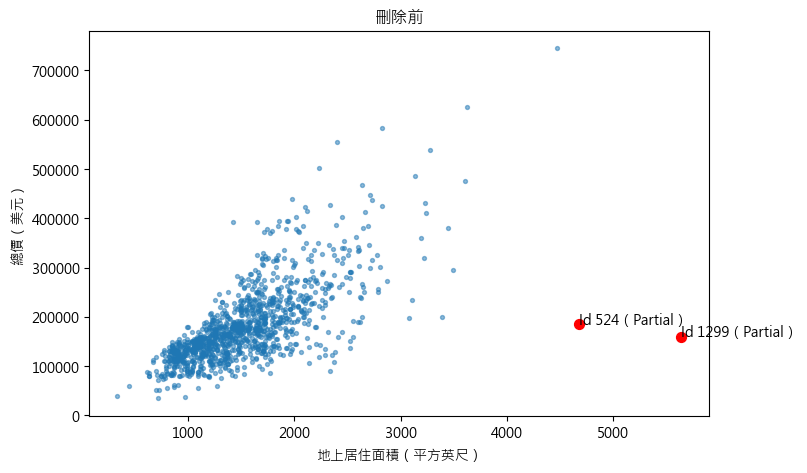

,Id,GrLivArea,SalePrice,SaleCondition
425,524,4676,184750,Partial
935,1183,4476,745000,Abnorml
1033,1299,5642,160000,Partial


In [5]:
# 問題：有沒有明顯異常的房子？
# 輸入：trainset 的 GrLivArea（地上居住面積）、SalePrice（總價）
# 輸出：散布圖（紅點 = 面積 > 4000 且總價 < 30 萬）
bad = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train.loc[~bad, "GrLivArea"], train.loc[~bad, "SalePrice"], s=8, alpha=0.5)
ax.scatter(train.loc[bad, "GrLivArea"], train.loc[bad, "SalePrice"], s=50, color="red")
for _, r in train[bad].iterrows():
    ax.annotate(f"Id {r['Id']}（{r['SaleCondition']}）", (r["GrLivArea"], r["SalePrice"]))
ax.set_xlabel("地上居住面積（平方英尺）"); ax.set_ylabel("總價（美元）"); ax.set_title("刪除前")
plt.show()
train.loc[train["GrLivArea"] > 4000, ["Id", "GrLivArea", "SalePrice", "SaleCondition"]]

**發現**：右下角 2 筆面積最大、價格卻很低，而且交易條件都是 `Partial`（預售屋，成交時還沒蓋好），成交價不代表完工後的市價。
另 1 筆面積也超過 4000 但價格很高，符合整體趨勢，不是異常。

**所以**：刪掉這 2 筆（條件：面積 > 4000 且總價 < 30 萬）。其他極端值不刪。
理由：極端值全部刪掉可能讓模型變差，因為 testset 裡也可能出現極端值；所以只刪這 2 筆「非常大又非常不合理」的，其餘交給模型處理（第 7 節的 RobustScaler 就是為了降低極端值的影響）。

**只刪 trainset，不刪 testset**：testset 代表未來要估的房子，不能因為難估就拿掉。

刪除的 Id: [524, 1299] ｜ trainset 剩 1166 筆
各折 validation 筆數: [233, 234, 234, 232, 233]


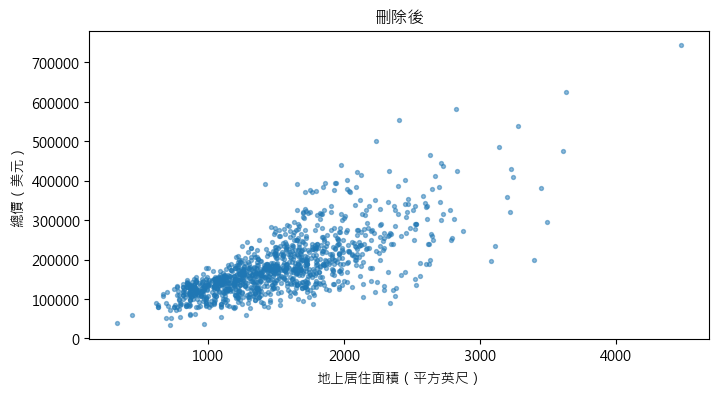

In [6]:
# 問題：刪掉 2 筆異常點
# 輸入：train
# 輸出：刪除後的 train；各折剩下的筆數
removed_ids = train.loc[bad, "Id"].tolist()
train = train[~bad].reset_index(drop=True)
print("刪除的 Id:", removed_ids, "｜ trainset 剩", len(train), "筆")
print("各折 validation 筆數:", train["CV_fold"].value_counts().sort_index().tolist())
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(train["GrLivArea"], train["SalePrice"], s=8, alpha=0.5)
ax.set_xlabel("地上居住面積（平方英尺）"); ax.set_ylabel("總價（美元）"); ax.set_title("刪除後")
plt.show()

# 2.Target 分布

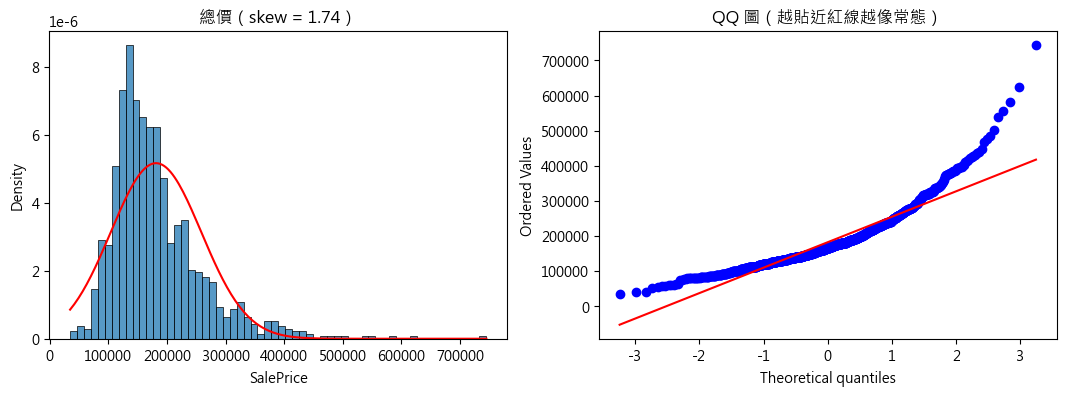

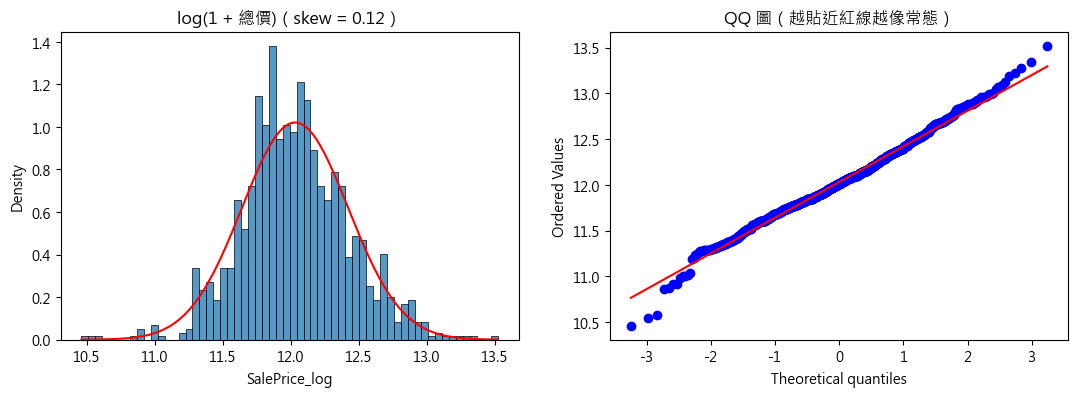

In [7]:
# 問題：總價是不是常態分布？
# 輸入：trainset 的 SalePrice
# 輸出：分布圖＋常態曲線、QQ 圖；原始與 log1p 後的偏態
def plot_dist(y, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(y, kde=False, stat="density", bins=60, ax=axes[0])
    mu, sigma = norm.fit(y)
    xs = np.linspace(y.min(), y.max(), 200)
    axes[0].plot(xs, norm.pdf(xs, mu, sigma), "r"); axes[0].set_title(f"{title}（skew = {skew(y):.2f}）")
    stats.probplot(y, plot=axes[1]); axes[1].set_title("QQ 圖（越貼近紅線越像常態）")
    plt.show()

plot_dist(train["SalePrice"], "總價")
train["SalePrice_log"] = np.log1p(train["SalePrice"])
test["SalePrice_log"] = np.log1p(test["SalePrice"])
plot_dist(train["SalePrice_log"], "log(1 + 總價)")

**發現**：總價右偏（第一張圖標題的 skew 明顯大於 0，QQ 圖右上翹起）；取 `log(1+總價)` 後 skew 接近 0，QQ 圖貼近紅線。
**理由**：線性模型假設誤差接近常態分布，對總價取 log 可以讓分布接近常態。

**所以**：檔案裡**同時保留** `總價美元`（原始）和 `log總價`（log1p 後）。用哪一個當 y 由 P3 在 CV 比較後決定（用 log 的話，預測完要用 `np.expm1()` 轉回美元再算誤差）。

# 3.Missing Data
先看缺值比例，再**逐欄**依說明檔補值。

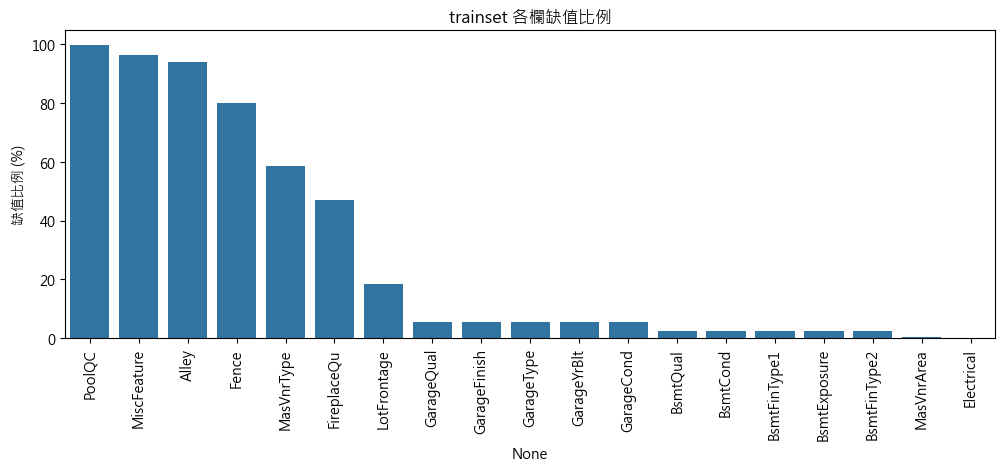

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,LotFrontage,GarageQual,GarageFinish,GarageType,GarageYrBlt,GarageCond,BsmtQual,BsmtCond,BsmtFinType1,BsmtExposure,BsmtFinType2,MasVnrArea,Electrical
缺值比例(%),99.6,96.1,93.7,80.0,58.6,46.9,18.6,5.5,5.5,5.5,5.5,5.5,2.4,2.4,2.4,2.4,2.4,0.5,0.1


In [8]:
# 問題：哪些欄位有缺值、缺多少？
# 輸入：trainset、testset
# 輸出：trainset 缺值比例表與長條圖
feat_cols = [c for c in train.columns if c not in ("Id", "CV_fold", "SalePrice", "SalePrice_log")]
na_ratio = (train[feat_cols].isnull().mean() * 100).sort_values(ascending=False)
na_ratio = na_ratio[na_ratio > 0]
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=na_ratio.index, y=na_ratio.values, ax=ax)
ax.set_ylabel("缺值比例 (%)"); ax.set_title("trainset 各欄缺值比例"); plt.xticks(rotation=90)
plt.show()
na_ratio.round(1).to_frame("缺值比例(%)").T

註：砌面類型（MasVnrType）的缺值比例很高，是因為 pandas 預設把原檔的字串 `None`（= 無砌面）也讀成 NaN；真正沒填的只有 6 筆左右，下面一律補 `None`，結果一樣是「無砌面」。

每一欄的處理與依據如下（`說明檔` = Kaggle 附的 `data_description.txt`）：

| 欄位 | 說明檔／發現 | 填什麼 |
|---|---|---|
| PoolQC、MiscFeature、Alley、Fence、FireplaceQu | 說明檔：NA = 沒有泳池／其他設施／巷道／圍籬／壁爐 | `None`（沒有） |
| GarageType、GarageFinish、GarageQual、GarageCond | 說明檔：NA = No Garage | `None` |
| GarageArea、GarageCars | 沒有車庫 → 車位、面積就是 0 | `0` |
| BsmtQual、BsmtCond、BsmtExposure、BsmtFinType1、BsmtFinType2 | 說明檔：NA = No Basement | `None`（但若同一列地下室總面積 > 0，表示有地下室只是沒填，改填 trainset 眾數，避免誤判成「沒有」） |
| BsmtFinSF1、BsmtFinSF2、BsmtUnfSF、TotalBsmtSF、BsmtFullBath、BsmtHalfBath | 沒有地下室 → 面積、衛浴數是 0 | `0` |
| MasVnrType、MasVnrArea | NA 很可能是沒有砌面 | 類型 `None`、面積 `0` |
| LotFrontage（臨街長度） | 同社區房子的臨街長度相近 | **同社區的中位數**（只用 trainset 算） |
| MSZoning、Electrical、KitchenQual、Exterior1st/2nd、SaleType | 只缺極少數，且某個值佔絕大多數 | **眾數**（只用 trainset 算） |
| Functional | 說明檔：假設為 Typical | `Typ` |
| Utilities | 幾乎全部是 AllPub，對預測沒幫助 | **drop 整欄** |
| GarageYrBlt（車庫建造年份） | 缺的都是沒有車庫的房子 | 補 0（西元 0 年）會變成超大極端值，補其他年份也不合理 → **drop 整欄** |

我們的資料有些欄位沒有缺值（例如 MSZoning、KitchenQual），程式照樣執行，對 testset 或未來新資料一樣有效。

In [9]:
# 問題：依上表逐欄補缺值
# 輸入：train、test
# 輸出：沒有缺值的 train、test
def fill_missing(df, ref):
    # df：要補的資料；ref：用來算眾數、中位數的資料（一律是 trainset）
    df = df.copy()
    for col in ("PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
                "GarageType", "GarageFinish", "GarageQual", "GarageCond", "MasVnrType"):
        df[col] = df[col].fillna("None")
    for col in ("GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
                "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"):
        df[col] = df[col].fillna(0)
    for col in ("BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"):
        has_bsmt = df["TotalBsmtSF"] > 0
        df.loc[df[col].isna() & has_bsmt, col] = ref[col].mode()[0]    # 有地下室只是沒填
        df[col] = df[col].fillna("None")                                 # 沒有地下室
    nb_median = ref.groupby("Neighborhood")["LotFrontage"].median()
    df["LotFrontage"] = df["LotFrontage"].fillna(df["Neighborhood"].map(nb_median)).fillna(ref["LotFrontage"].median())
    for col in ("MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType"):
        df[col] = df[col].fillna(ref[col].mode()[0])
    df["Functional"] = df["Functional"].fillna("Typ")
    df = df.drop(columns=["Utilities", "GarageYrBlt"])
    return df

train_ref = train.copy()                       # 補值前的 trainset，用來算眾數、中位數
before = train.isnull().sum(); before = before[before > 0]
train = fill_missing(train, train_ref)
test = fill_missing(test, train_ref)
print("補值後剩下的缺值：trainset", int(train.isnull().sum().sum()), "｜ testset", int(test.isnull().sum().sum()))
print("用 trainset 算出的數字：Electrical 眾數 =", train_ref["Electrical"].mode()[0],
      "｜ LotFrontage 整體中位數 =", train_ref["LotFrontage"].median())
before.to_frame("trainset 原本缺值筆數").T

補值後剩下的缺值：trainset 0 ｜ testset 0
用 trainset 算出的數字：Electrical 眾數 = SBrkr ｜ LotFrontage 整體中位數 = 70.0


,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
trainset 原本缺值筆數,217,1092,683,6,28,28,28,28,28,1,547,64,64,64,64,64,1161,933,1120


# 4.Duplicates 與高度相似資料

In [10]:
# 問題：有沒有一模一樣、或幾乎一樣的房子？
# 輸入：trainset
# 輸出：完全重複筆數；高度相似配對數
feat_cols = [c for c in train.columns if c not in ("Id", "CV_fold", "SalePrice", "SalePrice_log")]
print("完全重複（所有房屋欄位都一樣）:", int(train.duplicated(subset=feat_cols).sum()), "筆")
pairs = []
for _, g in train.groupby(["Neighborhood", "MSSubClass", "BldgType", "YearBuilt"]):
    g = g[["Id", "GrLivArea", "LotArea"]].to_numpy()
    for i in range(len(g)):
        for j in range(i + 1, len(g)):
            if abs(g[i, 1] - g[j, 1]) <= 0.02 * max(g[i, 1], g[j, 1]) and abs(g[i, 2] - g[j, 2]) <= 0.02 * max(g[i, 2], g[j, 2]):
                pairs.append((int(g[i, 0]), int(g[j, 0])))
print(f"高度相似（同社區、同類型、同建造年，面積差 2% 內）: {len(pairs)} 對，例如 {pairs[:5]}")

完全重複（所有房屋欄位都一樣）: 0 筆
高度相似（同社區、同類型、同建造年，面積差 2% 內）: 29 對，例如 [(1005, 1024), (1127, 1416), (90, 1308), (217, 1445), (705, 934)]


**判斷**：沒有完全重複，不用刪。相似的大多是同一批建案的連棟住宅，格局本來就一樣；資料沒有房產編號，無法證明是同一間房子，所以不刪、不合併。

# 5.中文化
把欄名和類別內容換成中文（依 `data_description.txt`），方便組員閱讀。`None` 依欄位換成「無泳池」「無車庫」等。
同時把 `MSSubClass`（住宅類型）從數字轉成文字：20、60、120 只是代碼，不是大小。

In [11]:
# 問題：英文欄名與代碼看不懂
# 輸入：train、test（英文）
# 輸出：train_zh、test_zh（中文）

NONE_ZH = {"PoolQC": "無泳池", "MiscFeature": "無其他設施", "Alley": "無巷道", "Fence": "無圍籬",
           "FireplaceQu": "無壁爐", "MasVnrType": "無砌面",
           **{c: "無車庫" for c in ("GarageType", "GarageFinish", "GarageQual", "GarageCond")},
           **{c: "無地下室" for c in ("BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2")}}
rename_dict.update({"CV_fold": "CV折號", "SalePrice_log": "log總價"})

def to_chinese(df):
    df = df.copy()
    df["MSSubClass"] = df["MSSubClass"].astype(str)
    for col, mapping in value_map.items():
        if col in df.columns:
            df[col] = df[col].map(lambda v, c=col, m=mapping: NONE_ZH[c] if v == "None" else m.get(v, v))
            missing = set(df[col]) - set(mapping.values()) - {NONE_ZH.get(col)}
            assert not missing, f"{col} 有沒翻到的值: {missing}"
    return df.rename(columns=rename_dict)

train_zh, test_zh = to_chinese(train), to_chinese(test)
train_zh.head(3)

,編號,CV折號,住宅類型,土地分區,臨街長度英尺,地塊面積平方英尺,道路鋪面,巷道,地塊形狀,地形,...,泳池品質,圍籬,其他設施,其他設施價值美元,成交月份,成交年份,交易類型,交易條件,總價美元,log總價
0,1,2,2層樓(1946年後),低密度住宅區,65.0,8450,柏油路,無巷道,規則,平坦,...,無泳池,無圍籬,無其他設施,0,2,2008,一般保證契約,一般交易,208500,12.247699
1,2,4,1層樓(1946年後),低密度住宅區,80.0,9600,柏油路,無巷道,規則,平坦,...,無泳池,無圍籬,無其他設施,0,5,2007,一般保證契約,一般交易,181500,12.109016
2,3,1,2層樓(1946年後),低密度住宅區,68.0,11250,柏油路,無巷道,略不規則,平坦,...,無泳池,無圍籬,無其他設施,0,9,2008,一般保證契約,一般交易,223500,12.317171


# 6.Encoding

**為什麼要編碼**：線性迴歸只能吃數字。

**① 有序類別 → 數字（手動指定順序）**
這些欄位「本身有好壞順序」：品質／狀況等級、地下室完工品質、採光、車庫內裝、坡度、地塊形狀等。
不用 `LabelEncoder`，因為它照字母排序，會得到 `極佳(Ex)=0、尚可(Fa)=1、良好(Gd)=2、差(Po)=3、普通(TA)=4`，順序錯了；
我們手動指定，例如 `無=0、差=1、尚可=2、普通=3、良好=4、極佳=5`，數字越大越好，模型才能學到「品質越好、價格越高」。

**② 其他名目類別 → One-hot（`pd.get_dummies`）**
例如社區、屋頂樣式，沒有大小順序，每個類別變成一個 0/1 欄。testset 對齊 trainset 的欄位，trainset 沒出現過的類別就全部是 0。

**不放進模型**：成交年份、成交月份、交易類型、交易條件（成交後才知道）。
`整體狀況1到10分` 跟 `整體品質1到10分` 一樣保留分數，兩欄處理方式一致。

In [12]:
# 問題：類別欄轉成數字
# 輸入：train_zh、test_zh
# 輸出：train_enc、test_enc（全部是數字）
QUALITY = {"差": 1, "尚可": 2, "普通": 3, "良好": 4, "極佳": 5}           # 前面加「無X」= 0
ORDINAL = {
    **{c: QUALITY for c in ["外牆品質", "外牆狀況", "地下室高度品質", "地下室狀況", "暖氣品質", "廚房品質",
                             "壁爐品質", "車庫品質", "車庫狀況", "泳池品質"]},
    "地下室完工區1品質": {"未完工": 1, "低品質空間": 2, "一般娛樂空間": 3, "低於平均居住空間": 4, "普通居住空間": 5, "優良居住空間": 6},
    "地下室完工區2品質": {"未完工": 1, "低品質空間": 2, "一般娛樂空間": 3, "低於平均居住空間": 4, "普通居住空間": 5, "優良居住空間": 6},
    "地下室採光": {"無採光": 1, "採光少": 2, "採光普通": 3, "採光良好": 4},
    "車庫內裝": {"未完工": 1, "粗略完工": 2, "已完工": 3},
    "居家功能性": {"僅剩殘值": 0, "嚴重受損": 1, "重大扣分2": 2, "重大扣分1": 3, "中度扣分": 4, "輕微扣分2": 5, "輕微扣分1": 6, "正常": 7},
    "圍籬": {"簡易鐵絲網": 1, "木圍籬佳": 2, "隱私性低": 3, "隱私性佳": 4},
    "坡度": {"陡坡": 0, "中坡": 1, "緩坡": 2},
    "地塊形狀": {"不規則": 0, "中度不規則": 1, "略不規則": 2, "規則": 3},
    "車道鋪面": {"泥土或碎石": 0, "部分鋪面": 1, "鋪面": 2},
    "道路鋪面": {"碎石路": 0, "柏油路": 1},
    "巷道": {"碎石巷": 1, "柏油巷": 2},
    "中央空調": {"無": 0, "有": 1},
}
NOT_FEATURE = ["編號", "CV折號", "總價美元", "log總價", "成交年份", "成交月份", "交易類型", "交易條件"]

def encode(df):
    df = df.copy()
    for col, order in ORDINAL.items():
        df[col] = df[col].map(lambda v, o=order: 0 if v.startswith("無") and v not in o else o[v])
    return df

train_enc, test_enc = encode(train_zh), encode(test_zh)
nominal = [c for c in train_enc.columns if train_enc[c].dtype == object and c not in NOT_FEATURE]
train_enc = pd.get_dummies(train_enc, columns=nominal, dtype=int)
test_enc = pd.get_dummies(test_enc, columns=nominal, dtype=int).reindex(columns=train_enc.columns, fill_value=0)
print(f"有序類別 {len(ORDINAL)} 欄 → 數字；名目類別 {len(nominal)} 欄 → One-hot")
print("例：廚房品質", train_zh["廚房品質"].head(3).tolist(), "→", train_enc["廚房品質"].head(3).tolist())
print("例：編號", train_zh["編號"][0], "社區 =", train_zh["社區"][0], "→",
      [c for c in train_enc.columns if c.startswith("社區_") and train_enc.loc[0, c] == 1])

有序類別 22 欄 → 數字；名目類別 19 欄 → One-hot
例：廚房品質 ['良好', '普通', '良好'] → [4, 3, 4]
例：編號 1 社區 = 學院溪(CollgCr) → ['社區_學院溪(CollgCr)']


# 7.偏態轉換（Box-Cox）＋ Scaling（RobustScaler）

**偏態轉換**：面積類的數值欄大多右偏。對 |skew| > 0.75 的欄位做 `boxcox1p(x, λ=0.15)`，把長尾壓短、讓分布接近常態，線性模型比較不會被少數大值主導。
（λ = 0 時就等於 log1p。）哪些欄要轉，只用 trainset 的 skew 決定。

**Scaling**：用 `RobustScaler`。Lasso、Ridge 等線性模型對極端值很敏感，RobustScaler 讓它更穩。
RobustScaler 用**中位數**和 **IQR（Q3−Q1）** 縮放，不像平均和標準差那樣容易被極端值拉動。這也是第 1 節只刪 2 筆的原因：其他極端值在這裡處理。
只用 trainset fit；只縮放數值欄，One-hot 的 0/1 欄不縮放。

In [13]:
# 問題：右偏的數值欄做 Box-Cox，再把數值欄縮放到相近尺度
# 輸入：train_enc、test_enc
# 輸出：最終的 train_final、test_final
dummy_cols = [c for c in train_enc.columns if c not in train_zh.columns]     # get_dummies 新產生的 0/1 欄
num_cols = [c for c in train_enc.columns if c not in NOT_FEATURE and c not in dummy_cols]

skewness = train_enc[num_cols].apply(lambda x: skew(x)).sort_values(ascending=False)
skewed = skewness[abs(skewness) > 0.75].index
print(f"|skew| > 0.75 的數值欄：{len(skewed)} 個（共 {len(num_cols)} 個數值欄）")
display(skewness.head(10).round(2).to_frame("trainset skew").T)

train_final, test_final = train_enc.copy(), test_enc.copy()
lam = 0.15
for col in skewed:
    train_final[col] = boxcox1p(train_final[col], lam)
    test_final[col] = boxcox1p(test_final[col], lam)
after = train_final[skewed].apply(lambda x: skew(x))
print(f"Box-Cox 後這些欄的平均 |skew|：{skewness[skewed].abs().mean():.2f} → {after.abs().mean():.2f}")
print("（泳池面積、三季門廊等「大多數是 0」的欄位，轉換後仍然偏，因為 0 的比例太高；面積、總價這類連續欄改善明顯）")
display(pd.DataFrame({"轉換前": skewness[["地上居住面積平方英尺", "一樓面積平方英尺", "地塊面積平方英尺", "泳池面積平方英尺"]], "轉換後": after.reindex(["地上居住面積平方英尺", "一樓面積平方英尺", "地塊面積平方英尺", "泳池面積平方英尺"])}).round(2).T)

scaler = RobustScaler().fit(train_final[num_cols])          # 只用 trainset
train_final[num_cols] = scaler.transform(train_final[num_cols])
test_final[num_cols] = scaler.transform(test_final[num_cols])
print(f"最終特徵：數值 {len(num_cols)} 欄 + One-hot {len(dummy_cols)} 欄 = {len(num_cols) + len(dummy_cols)} 欄")
train_final[["編號", "CV折號", "總價美元", "log總價"] + num_cols[:4] + dummy_cols[:2]].head(3)

|skew| > 0.75 的數值欄：35 個（共 54 個數值欄）


,其他設施價值美元,泳池品質,泳池面積平方英尺,地塊面積平方英尺,三季門廊面積平方英尺,低品質完工面積平方英尺,地上廚房數,巷道,地下室完工區2面積平方英尺,紗窗門廊面積平方英尺
trainset skew,22.01,17.62,15.67,12.33,9.81,9.18,4.43,4.29,4.21,4.08


Box-Cox 後這些欄的平均 |skew|：5.05 → 3.84
（泳池面積、三季門廊等「大多數是 0」的欄位，轉換後仍然偏，因為 0 的比例太高；面積、總價這類連續欄改善明顯）


,地上居住面積平方英尺,一樓面積平方英尺,地塊面積平方英尺,泳池面積平方英尺
轉換前,0.98,0.80,12.33,15.67
轉換後,0.08,0.07,0.90,15.20


最終特徵：數值 54 欄 + One-hot 159 欄 = 213 欄


,編號,CV折號,總價美元,log總價,臨街長度英尺,地塊面積平方英尺,道路鋪面,巷道,住宅類型_1.5層樓(已完工),住宅類型_1.5層樓(未完工)
0,1,2,208500,12.247699,-0.256476,-0.293154,0.0,0.0,0,0
1,2,4,181500,12.109016,0.469964,0.000000,0.0,0.0,0,0
2,3,1,223500,12.317171,-0.100689,0.372311,0.0,0.0,0,0


# 8.存檔、理由總表、驗收

**P3 使用方式**
```python
train = pd.read_csv("outputs/p1/train.csv")
X = train.drop(columns=["編號", "CV折號", "總價美元", "log總價", "成交年份", "成交月份", "交易類型", "交易條件"])
y = train["log總價"]          # 或 train["總價美元"]，由 P3 比較後決定
for k in range(5):            # 5 折：CV折號 == k 的當 validation
    tr, va = train["CV折號"] != k, train["CV折號"] == k
```
Note : 已知限制：中位數、眾數、Box-Cox 要轉哪些欄、RobustScaler 參數都是用整個 trainset 算的，所以 P3 做 5 折 CV 時，validation 折的資訊有一點點混進這些數字。
影響很小（只是補值與縮放的參數），但報告的 Experimental Setup 要寫一句。若要完全避免，P3 可以在每一折用 `train_readable.csv` 重跑第 3、6、7 節的函式。

In [14]:
# 問題：存檔，並整理每個前處理步驟的理由
# 輸入：train_final、test_final、train_zh、test_zh、split_df
# 輸出：outputs/p1/ 下 5 個檔案；理由總表
train_final.to_csv(OUTPUT_DIR / "train.csv", index=False, encoding="utf-8-sig")
test_final.to_csv(OUTPUT_DIR / "test.csv", index=False, encoding="utf-8-sig")
train_zh.to_csv(OUTPUT_DIR / "train_readable.csv", index=False, encoding="utf-8-sig")
test_zh.to_csv(OUTPUT_DIR / "test_readable.csv", index=False, encoding="utf-8-sig")
split_df.to_csv(OUTPUT_DIR / "data_split.csv", index=False)

REASONS = pd.DataFrame([
    ["Outliers 檢查", "地上居住面積 vs 總價散布圖", f"面積 > 4000 且總價 < 30 萬：{len(removed_ids)} 筆（Id {removed_ids}），都是預售屋", "原作者說明文件提醒"],
    ["Outlier handling", "只刪上述 2 筆（只刪 trainset）", "其他極端值保留，交給 RobustScaler", "全刪會讓模型遇到 testset 的極端值時更差"],
    ["Missing 檢查", "缺值比例表與長條圖", f"trainset 有 {len(before)} 欄有缺值", "依說明檔逐欄判斷"],
    ["Missing handling", "逐欄依說明檔補：None／0／同社區中位數／眾數；drop Utilities、車庫建造年份", "補完 trainset、testset 缺值皆為 0", "說明檔定義 NA = 沒有；統計值只用 trainset"],
    ["Duplicates／相似", "完全重複檢查＋相似配對", f"完全重複 0 筆、相似 {len(pairs)} 對", "無房產編號無法證明同一間，不刪"],
    ["Encoding", f"有序 {len(ORDINAL)} 欄手動排序編號；名目 {len(nominal)} 欄 One-hot", f"One-hot 後 {len(dummy_cols)} 欄", "線性迴歸只吃數字；LabelEncoder 字母順序錯誤，改手動"],
    ["偏態轉換", f"|skew|>0.75 的 {len(skewed)} 欄做 boxcox1p(λ=0.15)", f"平均 |skew| {skewness[skewed].abs().mean():.2f} → {after.abs().mean():.2f}", "線性模型偏好接近常態的分布"],
    ["Target", "保留原始總價，另加 log總價", f"skew {skew(train['SalePrice']):.2f} → {skew(train['SalePrice_log']):.2f}", "log 後接近常態；用哪個由 P3 決定"],
    ["Scaling", f"RobustScaler（只用 trainset fit）縮放 {len(num_cols)} 個數值欄", "One-hot 欄不縮放", "Lasso 對極端值敏感，Robust 版用中位數與 IQR"],
], columns=["步驟", "做法", "實際結果", "理由／依據"])
with pd.option_context("display.max_colwidth", 120):
    display(REASONS)

tr = pd.read_csv(OUTPUT_DIR / "train.csv"); te = pd.read_csv(OUTPUT_DIR / "test.csv")
feat = [c for c in tr.columns if c not in NOT_FEATURE]
check = {
    f"trainset {len(tr)} 筆（1,168 − 刪除 {len(removed_ids)}）、testset {len(te)} 筆": len(tr) == 1168 - len(removed_ids) and len(te) == 292,
    "train 與 test 編號不重疊": not set(tr["編號"]) & set(te["編號"]),
    "train、test 欄位完全相同": list(tr.columns) == list(te.columns),
    "特徵欄全部是數字、沒有缺值": all(pd.api.types.is_numeric_dtype(tr[c]) for c in feat) and not tr[feat].isna().any().any() and not te[feat].isna().any().any(),
    "每一筆 train 都有 CV折號（0–4）": tr["CV折號"].between(0, 4).all(),
    "data_split.csv 切分 1,168／292": (split_df["split"] == "train").sum() == 1168 and (split_df["split"] == "test").sum() == 292,
}
display(pd.Series({k: "✅" if v else "❌" for k, v in check.items()}, name="驗收").to_frame())
assert all(check.values())
print(f"train.csv：{tr.shape}，其中特徵 {len(feat)} 欄")

,步驟,做法,實際結果,理由／依據
0,Outliers 檢查,地上居住面積 vs 總價散布圖,"面積 > 4000 且總價 < 30 萬：2 筆（Id [524, 1299]），都是預售屋",原作者說明文件提醒
1,Outlier handling,只刪上述 2 筆（只刪 trainset）,其他極端值保留，交給 RobustScaler,全刪會讓模型遇到 testset 的極端值時更差
2,Missing 檢查,缺值比例表與長條圖,trainset 有 19 欄有缺值,依說明檔逐欄判斷
3,Missing handling,逐欄依說明檔補：None／0／同社區中位數／眾數；drop Utilities、車庫建造年份,補完 trainset、testset 缺值皆為 0,說明檔定義 NA = 沒有；統計值只用 trainset
4,Duplicates／相似,完全重複檢查＋相似配對,完全重複 0 筆、相似 29 對,無房產編號無法證明同一間，不刪
5,Encoding,有序 22 欄手動排序編號；名目 19 欄 One-hot,One-hot 後 159 欄,線性迴歸只吃數字；LabelEncoder 字母順序錯誤，改手動
6,偏態轉換,|skew|>0.75 的 35 欄做 boxcox1p(λ=0.15),平均 |skew| 5.05 → 3.84,線性模型偏好接近常態的分布
7,Target,保留原始總價，另加 log總價,skew 1.74 → 0.12,log 後接近常態；用哪個由 P3 決定
8,Scaling,RobustScaler（只用 trainset fit）縮放 54 個數值欄,One-hot 欄不縮放,Lasso 對極端值敏感，Robust 版用中位數與 IQR


,驗收
"trainset 1166 筆（1,168 − 刪除 2）、testset 292 筆",✅
train 與 test 編號不重疊,✅
train、test 欄位完全相同,✅
特徵欄全部是數字、沒有缺值,✅
每一筆 train 都有 CV折號（0–4）,✅
"data_split.csv 切分 1,168／292",✅


train.csv：(1166, 221)，其中特徵 213 欄
